<a href="https://colab.research.google.com/github/SEIF-ALDEN-HAMADA/DL-project-BANK-Marketing/blob/main/DL_Project(All_opt%2C_func_%26_seq).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df = pd.read_csv('/content/Bank Marketing (1).csv')

In [ ]:
df.head()

In [ ]:
df.info()

In [ ]:
cat_cols = df.select_dtypes("object")
df[cat_cols.columns] = cat_cols.astype("category")

In [ ]:
df.info()


In [ ]:
df.columns

In [ ]:
df.drop(['default','day_of_week','duration'], axis = 1, inplace=True)

In [ ]:
df.columns

In [ ]:
df.isna().sum()

In [ ]:
df['y'].value_counts()

In [ ]:
df['y'] = df['y'].map({'yes' : 1 , 'no' : 0})

In [ ]:
df['y'] = df["y"].astype("float")

In [ ]:
df.info()

In [ ]:
df['y'].unique()

In [ ]:
x = df.drop(columns=['y'])
y = df['y']

In [ ]:
from imblearn.under_sampling import RandomUnderSampler
rus = RandomUnderSampler(sampling_strategy='auto', random_state=42)
x_resampled, y_resampled = rus.fit_resample(x, y)

In [ ]:
print(pd.Series(y_resampled).value_counts())

In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
x_train, x_test, y_train, y_test = train_test_split(x_resampled, y_resampled, test_size=.2, random_state=42)

In [ ]:
x_train.shape

In [ ]:
x_test.shape

In [ ]:
y_train.shape

In [ ]:
y_test.shape

In [ ]:
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, LabelEncoder

cat_cols = df.select_dtypes("object")
num_cols = df.select_dtypes("float")

scaler = MinMaxScaler()
x_train_num = scaler.fit_transform(x_train[num_cols])
x_test_num = scaler.transform(x_test[num_cols])

encoder = OneHotEncoder(handle_unknown='ignore')
x_train = encoder.fit_transform(x_train[cat_cols])
x_test = encoder.transform(x_test[cat_cols])






Optimizer: SGD


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.02 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

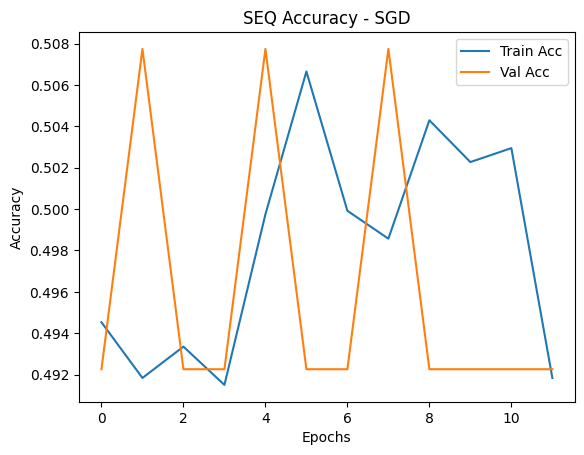

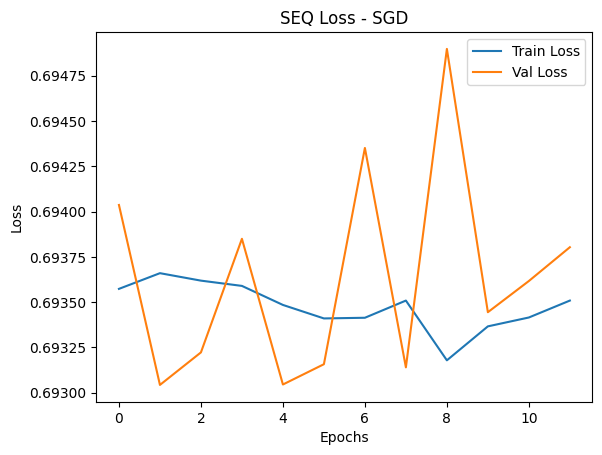

Model: "functional_5"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 12)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 64)             │           832 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,587 (14.02 KB)

 Trainable params: 3,585 (14.00 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 2 (12.00 B)

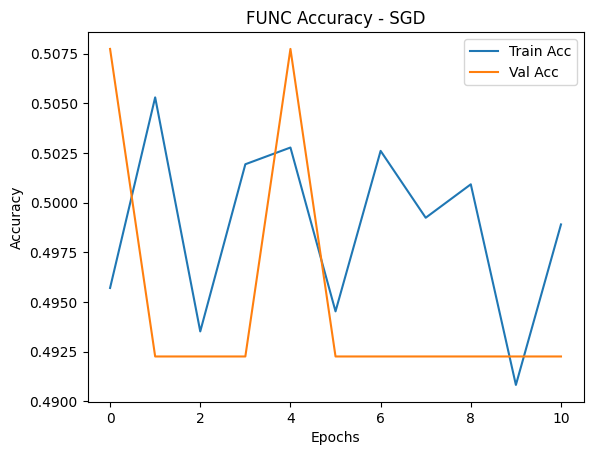

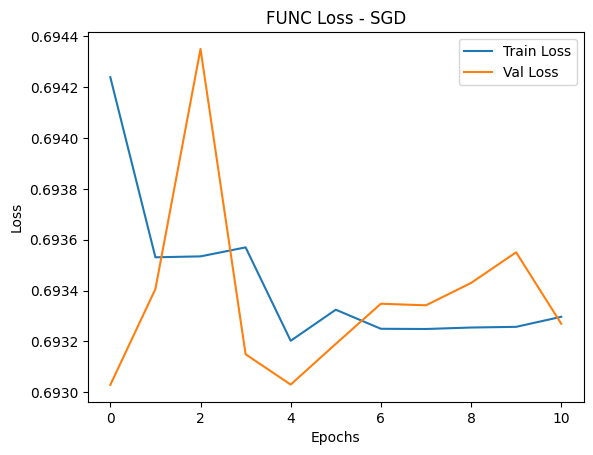


Optimizer: SGD_momentum


In [ ]:
import tensorflow as tf
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential, Model
from tensorflow.keras.layers import Dense, Input, InputLayer
from tensorflow.keras.optimizers import SGD, Adagrad, RMSprop, Adam
from tensorflow.keras.callbacks import EarlyStopping
import warnings
warnings.filterwarnings('ignore')

tf.config.run_functions_eagerly(True)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=10,
    restore_best_weights=True)


optimizers = {
    'SGD': lambda: SGD(learning_rate=0.01),
    'SGD_momentum': lambda: SGD(learning_rate=0.01, momentum=0.9),
    'Adagrad': lambda: Adagrad(learning_rate=0.01),
    'RMSprop': lambda: RMSprop(learning_rate=0.001),
    'Adam': lambda: Adam(learning_rate=0.001)
}

# Sequential
def sequential_model(input_dim):
    model = Sequential()
    model.add(InputLayer(input_shape=(input_dim,), sparse=True))
    model.add(Dense(64, activation='relu'))
    model.add(Dense(32, activation='relu'))
    model.add(Dense(16, activation='relu'))
    model.add(Dense(8, activation='relu'))
    model.add(Dense(1, activation='sigmoid'))
    return model

# Functional
def functional_model(input_dim):
    inp = Input(shape=(input_dim,), sparse=True)
    x1 = Dense(64, activation='relu')(inp)
    x2 = Dense(32, activation='relu')(x1)
    x3 = Dense(16, activation='relu')(x2)
    x4 = Dense(8, activation='relu')(x3)
    out = Dense(1, activation='sigmoid')(x4)
    return Model(inputs=inp, outputs=out)

# Training
for name, opt_fn in optimizers.items():
    print(f'\nOptimizer: {name}')

    # Sequential
    model = sequential_model(x_train.shape[1])
    model.compile(optimizer=opt_fn(), loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train,
                        epochs=100,
                        batch_size=16,
                        validation_data=(x_test, y_test),
                        callbacks=[early_stop], verbose=0)

    #plotting
    model.summary()

    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'SEQ Accuracy - {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'SEQ Loss - {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()

    # Functional model
    model = functional_model(x_train.shape[1])
    model.compile(optimizer=opt_fn(), loss='binary_crossentropy', metrics=['accuracy'])
    history = model.fit(x_train, y_train,
                        epochs=100, batch_size=16,
                        validation_data=(x_test, y_test),
                        callbacks=[early_stop], verbose=0)

    model.summary()

    plt.plot(history.history['accuracy'], label='Train Acc')
    plt.plot(history.history['val_accuracy'], label='Val Acc')
    plt.title(f'FUNC Accuracy - {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Accuracy')
    plt.legend()
    plt.show()

    plt.plot(history.history['loss'], label='Train Loss')
    plt.plot(history.history['val_loss'], label='Val Loss')
    plt.title(f'FUNC Loss - {name}')
    plt.xlabel('Epochs')
    plt.ylabel('Loss')
    plt.legend()
    plt.show()